# 实战项目：薪资决定因素实证分析


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy.stats import norm
from scipy import stats
import statsmodels.formula.api as smf
import scipy.stats as st
from itables import show
from ydata_profiling import ProfileReport
#加载主题包
from jupyterthemes import jtplot
jtplot.style(theme='oceans16')

#多行打印设置
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [2]:
import wooldridge

In [3]:
df = wooldridge.data('wage1', description=True)

name of dataset: wage1
no of variables: 24
no of observations: 526

+----------+---------------------------------+
| variable | label                           |
+----------+---------------------------------+
| wage     | average hourly earnings         |
| educ     | years of education              |
| exper    | years potential experience      |
| tenure   | years with current employer     |
| nonwhite | =1 if nonwhite                  |
| female   | =1 if female                    |
| married  | =1 if married                   |
| numdep   | number of dependents            |
| smsa     | =1 if live in SMSA              |
| northcen | =1 if live in north central U.S |
| south    | =1 if live in southern region   |
| west     | =1 if live in western region    |
| construc | =1 if work in construc. indus.  |
| ndurman  | =1 if in nondur. manuf. indus.  |
| trcommpu | =1 if in trans, commun, pub ut  |
| trade    | =1 if in wholesale or retail    |
| services | =1 if in services indus.  

In [4]:
data = wooldridge.data('wage1')

# 第一步：探索数据

In [ ]:
print(data[['price', 'sqrft', 'bdrms']].describe())

In [6]:
show(data)

Loading ITables v2.5.2 from the internet... (need help?)


In [7]:
profile = ProfileReport(data, title="wage1数据探索 报告")
profile.to_notebook_iframe()  # 在 Jupyter 中显示

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████████████████████████████████████████████| 24/24 [00:00<00:00, 63.28it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
#探索y变量
data['wage'].describe()

count    526.000000
mean       5.896103
std        3.693086
min        0.530000
25%        3.330000
50%        4.650000
75%        6.880000
max       24.980000
Name: wage, dtype: float64

In [13]:
sns.distplot(data['wage'],fit=norm)
fig=plt.figure()
res=stats.probplot(data['wage'],plot=plt)

/tmp/ipykernel_19828/2708003094.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['wage'],fit=norm)


<Axes: xlabel='wage', ylabel='Density'>

In [14]:
sns.displot(data['wage'], kde=True, stat="density")

<Axes: xlabel='wage', ylabel='Density'>

Text(0.5, 1.0, 'Wage Distribution')

((array([-3.00752959e+00, -2.72691749e+00, -2.56922767e+00, -2.45746379e+00,
         -2.36992204e+00, -2.29747862e+00, -2.23539961e+00, -2.18090058e+00,
         -2.13219992e+00, -2.08808619e+00, -2.04769693e+00, -2.01039547e+00,
         -1.97569798e+00, -1.94322781e+00, -1.91268583e+00, -1.88383034e+00,
         -1.85646313e+00, -1.83041961e+00, -1.80556149e+00, -1.78177146e+00,
         -1.75894911e+00, -1.73700778e+00, -1.71587217e+00, -1.69547638e+00,
         -1.67576245e+00, -1.65667907e+00, -1.63818062e+00, -1.62022634e+00,
         -1.60277966e+00, -1.58580763e+00, -1.56928048e+00, -1.55317118e+00,
         -1.53745515e+00, -1.52210995e+00, -1.50711502e+00, -1.49245150e+00,
         -1.47810204e+00, -1.46405064e+00, -1.45028250e+00, -1.43678392e+00,
         -1.42354217e+00, -1.41054543e+00, -1.39778268e+00, -1.38524364e+00,
         -1.37291869e+00, -1.36079883e+00, -1.34887564e+00, -1.33714117e+00,
         -1.32558800e+00, -1.31420909e+00, -1.30299785e+00, -1.29194804e+00,

Text(0.5, 1.0, 'Probability Plot')

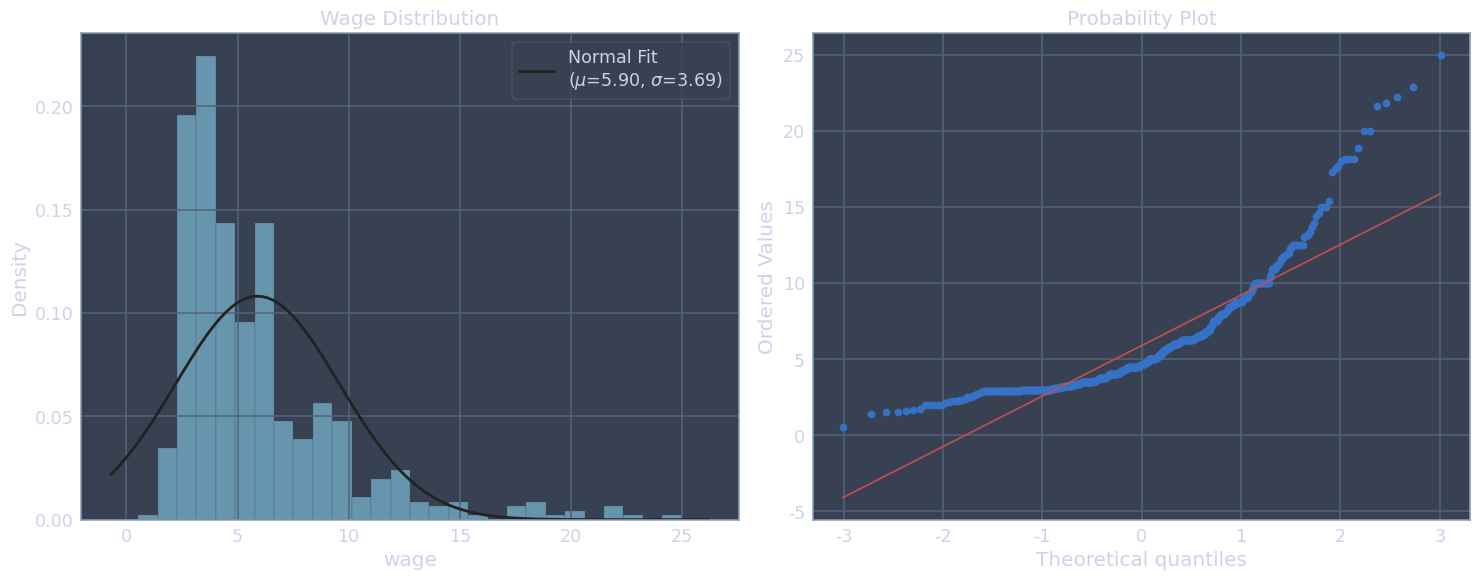

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# --- 接下来直接粘贴我之前给你的合并绘图代码 ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 左图
sns.histplot(data['wage'], kde=False, stat='density', color='skyblue', alpha=0.6, ax=axes[0])
mu, std = stats.norm.fit(data['wage'].dropna()) # 加上 dropna() 防止空值报错
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
axes[0].plot(x, p, 'k', linewidth=2, label=f'Normal Fit\n($\mu$={mu:.2f}, $\sigma$={std:.2f})')
axes[0].set_title('Wage Distribution')
axes[0].legend()

# 右图
stats.probplot(data['wage'].dropna(), plot=axes[1])
axes[1].set_title('Probability Plot')

plt.tight_layout()
plt.show()